# Model-Based Feature Selection
I wanted to compare model-based selectors on the breast-cancer dataset after adding 50 random noise columns. My goal was to see which method could keep the real signal without letting the extra features leak into the test set.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

def evaluate_model(name, estimator, X_train, X_test, y_train, y_test):
    estimator.fit(X_train, y_train)
    preds = estimator.predict(X_test)
    probs = estimator.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }


## Data setup
I split the data first and only fit each selector on the training rows. Adding fake noise columns made it easier for me to judge whether a selector was finding useful structure or just grabbing extra dimensions.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = cancer.target.copy()

rng = np.random.default_rng(42)
noise = pd.DataFrame(
    rng.normal(size=(len(X), 50)),
    columns=[f"noise_{i:02d}" for i in range(50)],
    index=X.index,
)
X_full = pd.concat([X, noise], axis=1)

# I split before feature selection so the test set stays untouched.
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "positive_rate": [y_train.mean(), y_test.mean()],
    "columns": [X_train.shape[1], X_test.shape[1]],
}).set_index("split")
display(split_summary)


,rows,positive_rate,columns
split,,,
train,426,0.626761,80
test,143,0.629371,80


## Baseline vs selectors
I kept the baseline as scaled logistic regression, then compared a forest-based selector with an L1-based selector. For the L1 path I scaled before fitting the selector because coefficient penalties depend on feature scale.

In [3]:
baseline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42)),
])

forest_pipeline = Pipeline([
    ("select", SelectFromModel(
        RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=1),
        threshold="median",
    )),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42)),
])

l1_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectFromModel(
        LogisticRegression(
            C=0.2,
            l1_ratio=1.0,
            solver="liblinear",
            max_iter=5000,
            random_state=42,
        ),
        threshold="1.25*mean",
    )),
    ("model", LogisticRegression(max_iter=5000, random_state=42)),
])

models = {
    "baseline_logreg": baseline,
    "forest_selector": forest_pipeline,
    "l1_selector": l1_pipeline,
}

results = pd.DataFrame([
    evaluate_model(name, estimator, X_train, X_test, y_train, y_test)
    for name, estimator in models.items()
]).set_index("model").sort_values(["roc_auc", "accuracy"], ascending=False)

display(results.round(3))


,accuracy,roc_auc
model,,
l1_selector,0.986,0.997
forest_selector,0.972,0.994
baseline_logreg,0.958,0.989


,real_features,noise_features,total_selected
forest_selector,30,10,40
l1_selector,9,0,9


,forest_selected,l1_selected
0,mean radius,mean texture
1,mean texture,mean concave points
2,mean perimeter,radius error
3,mean area,worst radius
4,mean smoothness,worst texture
5,mean compactness,worst area
6,mean concavity,worst smoothness
7,mean concave points,worst concave points
8,mean symmetry,worst symmetry
9,mean fractal dimension,NaN


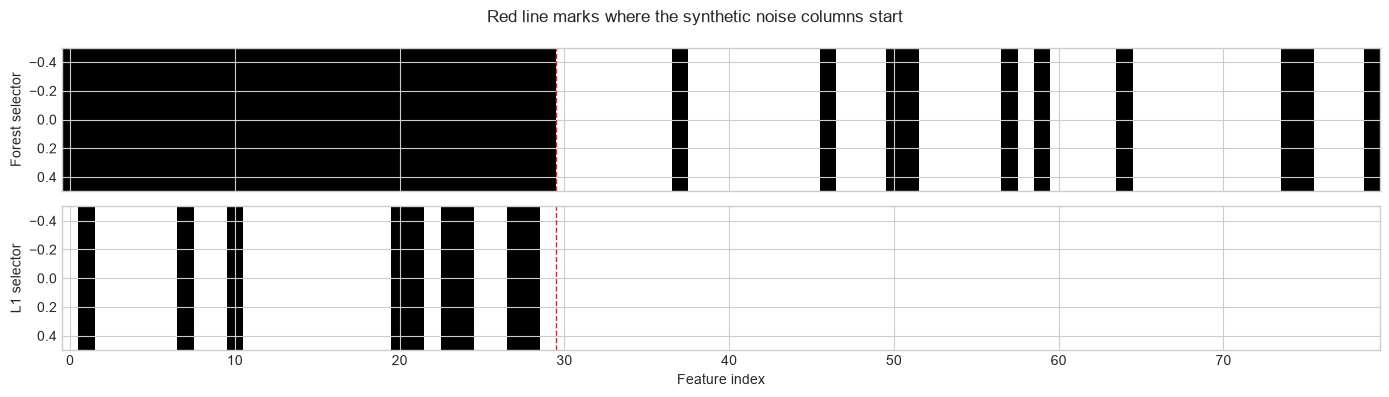

In [4]:
forest_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=1),
    threshold="median",
)
forest_selector.fit(X_train, y_train)
forest_support = pd.Series(forest_selector.get_support(), index=X_train.columns)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
# A median threshold becomes 0 here, so I used a stricter cutoff.
l1_selector = SelectFromModel(
    LogisticRegression(
        C=0.2,
        l1_ratio=1.0,
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    ),
    threshold="1.25*mean",
)
l1_selector.fit(X_train_scaled, y_train)
l1_support = pd.Series(l1_selector.get_support(), index=X_train.columns)

selection_summary = pd.DataFrame({
    "real_features": [forest_support.loc[X.columns].sum(), l1_support.loc[X.columns].sum()],
    "noise_features": [forest_support.loc[noise.columns].sum(), l1_support.loc[noise.columns].sum()],
}, index=["forest_selector", "l1_selector"])
selection_summary["total_selected"] = selection_summary.sum(axis=1)
display(selection_summary)

selected_feature_table = pd.DataFrame({
    "forest_selected": pd.Series(forest_support[forest_support].index),
    "l1_selected": pd.Series(l1_support[l1_support].index),
})
display(selected_feature_table.head(15))

fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
for ax, support, label in zip(axes, [forest_support, l1_support], ["Forest selector", "L1 selector"]):
    ax.imshow(support.to_numpy().reshape(1, -1), aspect="auto", cmap="gray_r")
    ax.axvline(len(X.columns) - 0.5, color="tab:red", linestyle="--", linewidth=1)
    ax.set_ylabel(label)
axes[1].set_xlabel("Feature index")
plt.suptitle("Red line marks where the synthetic noise columns start")
plt.tight_layout()
plt.show()


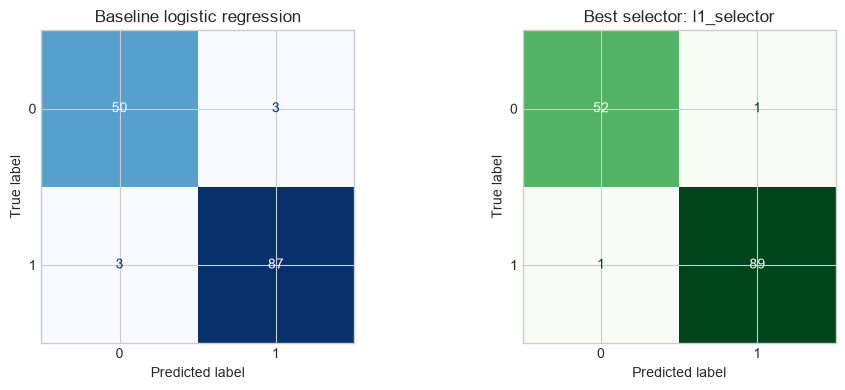

In [5]:
best_selector_name = results.loc[["forest_selector", "l1_selector"]]["roc_auc"].idxmax()
best_selector = models[best_selector_name]
baseline.fit(X_train, y_train)
best_selector.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(
    baseline, X_test, y_test, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Baseline logistic regression")
ConfusionMatrixDisplay.from_estimator(
    best_selector, X_test, y_test, ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title(f"Best selector: {best_selector_name}")
plt.tight_layout()
plt.show()


## What I learned
The baseline was already strong at about 0.989 ROC AUC, so adding fifty fake columns did not break the problem by itself. The L1 selector felt cleaner to me because it kept only 9 original features, dropped every noise column, and still reached about 0.997 ROC AUC, while the forest selector kept 10 noise columns along with all 30 real ones.